# 06 · Autocorrelation and ARMA Models

Every chapter so far has run into the same fact about PM2.5: **today says a lot about tomorrow, and very little about next week**. Naive captured the first half, climatology the second, and exponential smoothing could only switch between them. What we need is a model that *remembers* recent values and *lets that memory fade gradually* towards a typical level.

That's exactly what **autoregressive moving-average (ARMA)** models do. They're the workhorses of classical time-series analysis. This chapter builds them from the ground up, starting with the tools that reveal a series' memory, the ACF and PACF, and ending with the best forecasts on our scoreboard so far.

**By the end of this chapter you will be able to**

- compute and read the **autocorrelation (ACF)** and **partial autocorrelation (PACF)** functions, and implement both from scratch
- describe **AR**, **MA** and **ARMA** processes, and recognise their ACF/PACF fingerprints
- fit ARMA models, choose orders with **AIC/BIC**, and check residuals with the **Ljung–Box** test
- explain why ARMA forecasts **revert to the mean**, and why their intervals **stop widening**
- combine a seasonal profile with an ARMA model for the deviations, and backtest it honestly

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import acf, pacf
from scipy.signal import lfilter

import tsutils

tsutils.set_style()
pd.set_option("display.precision", 3)

daily = tsutils.load_daily_pm25()
y, actual = daily["pm25"], daily["actual"]
origins, H = tsutils.BACKTEST_ORIGINS, tsutils.HORIZON

---
## 1. The autocorrelation function (ACF)

The **autocorrelation at lag $k$** is the correlation between the series and itself shifted by $k$ steps. For a sample $y_1, \dots, y_n$ with mean $\bar y$, the standard estimate is

$$r_k = \frac{\sum_{t=k+1}^{n} (y_t - \bar y)(y_{t-k} - \bar y)}{\sum_{t=1}^{n} (y_t - \bar y)^2}.$$

Note the denominator: it uses **all** $n$ terms, not just the $n - k$ overlapping ones. That shrinks long-lag estimates slightly towards zero, but it guarantees the ACF behaves like a proper autocorrelation function, which is why every library uses it.

In [2]:
def sample_acf(x, max_lag):
    x = np.asarray(x, dtype=float) - np.mean(x)
    denominator = np.sum(x * x)
    return np.array([np.sum(x[k:] * x[:-k]) / denominator for k in range(1, max_lag + 1)])

log_y = np.log(y)
print("matches statsmodels:", np.allclose(sample_acf(log_y, 10), acf(log_y, nlags=10)[1:]))

matches statsmodels: True


### How big is "significant"?

If the series were **white noise**, each $r_k$ would be approximately normal with mean 0 and standard deviation $1/\sqrt{n}$. So values outside $\pm 1.96/\sqrt{n}$ are unusual *for white noise*: that's the shaded band on every ACF plot.

Two cautions when reading those bands. First, with 30 lags on the plot, about **1 or 2 will poke outside by chance** even for pure noise, since each has a 5% chance. Don't build a model around one marginal spike. Second, the band assumes white noise. Once the early lags are clearly non-zero, later lags have wider uncertainty than the band suggests.

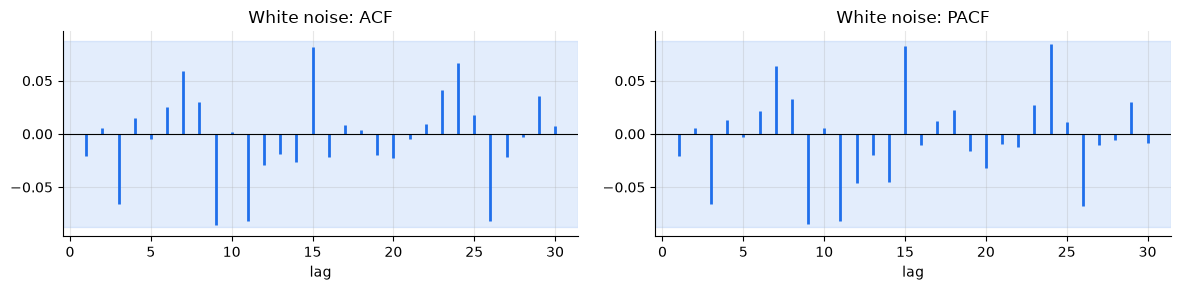

In [3]:
def plot_acf_pacf(series, lags=20, title="", theory=None):
    """Sample ACF and PACF as stems, optional theoretical values as dots, with ±1.96/√n bands."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    band = 1.96 / np.sqrt(len(series))
    k = np.arange(1, lags + 1)
    for ax, name, values in [(axes[0], "ACF", acf(series, nlags=lags)[1:]),
                             (axes[1], "PACF", pacf(series, nlags=lags)[1:])]:
        ax.vlines(k, 0, values, lw=2)
        ax.axhline(0, color="k", lw=0.8)
        ax.axhspan(-band, band, color="#1f6feb", alpha=0.12)
        if theory is not None:
            ax.plot(k, theory[name], "o", color="#d1495b", ms=4, label="theory")
            ax.legend(loc="upper right", fontsize=8)
        ax.set(title=f"{title} {name}".strip(), xlabel="lag")
    fig.tight_layout()

rng = np.random.default_rng(0)
plot_acf_pacf(pd.Series(rng.normal(size=500)), lags=30, title="White noise:")

---
## 2. The partial autocorrelation function (PACF)

The ACF has a blind spot. If today depends on yesterday, and yesterday on the day before, then today and the day before will be correlated **even if there's no direct link** between them. The correlation is passed along the chain.

The **partial autocorrelation at lag $k$** removes that relay effect. It's the correlation between $y_t$ and $y_{t-k}$ **after accounting for the lags in between**. The clearest way to compute it is by regression: regress $y_t$ on $y_{t-1}, \dots, y_{t-k}$, and the coefficient on $y_{t-k}$ is the PACF at lag $k$.

In [4]:
def sample_pacf(x, max_lag):
    """PACF(k) = last coefficient when regressing y_t on a constant and y_{t-1}, ..., y_{t-k}."""
    x = np.asarray(x, dtype=float)
    out = []
    for k in range(1, max_lag + 1):
        target = x[k:]
        lagged = [x[k - j:-j] for j in range(1, k + 1)]
        design = np.column_stack([np.ones(len(target))] + lagged)
        coefficients = np.linalg.lstsq(design, target, rcond=None)[0]
        out.append(coefficients[-1])
    return np.array(out)

print("matches statsmodels (OLS method):",
      np.allclose(sample_pacf(log_y, 10), pacf(log_y, nlags=10, method="ols")[1:]))

matches statsmodels (OLS method): True


(statsmodels' default PACF uses a slightly different estimator, Yule–Walker, which gives nearly the same values on long series. Our plots use the default.)

---
## 3. A zoo of processes and their fingerprints

**Autoregressive, AR($p$):** today is a weighted sum of the last $p$ values plus a new shock,

$$y_t = c + \phi_1 y_{t-1} + \dots + \phi_p y_{t-p} + \varepsilon_t.$$

**Moving average, MA($q$):** today is a weighted sum of the last $q$ **shocks**,

$$y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}.$$

> ⚠️ An MA *model* has nothing to do with moving-average *smoothing* from chapter 01. The name is historical. An MA model says today is built from recent **random shocks**, not from an average of recent observations.

**ARMA($p, q$)** has both parts. Each has a characteristic fingerprint:

| Process | ACF | PACF |
|---|---|---|
| AR($p$) | tails off gradually (decay, possibly oscillating) | **cuts off** after lag $p$ |
| MA($q$) | **cuts off** after lag $q$ | tails off gradually |
| ARMA($p,q$) | tails off | tails off |

The logic: in an AR($p$), once you know the last $p$ values, nothing older adds information, so the PACF stops. In an MA($q$), a shock is forgotten after $q$ steps, so the ACF stops.

statsmodels' `ArmaProcess` simulates any ARMA process and also gives its **theoretical** ACF and PACF, which we'll overlay as dots.

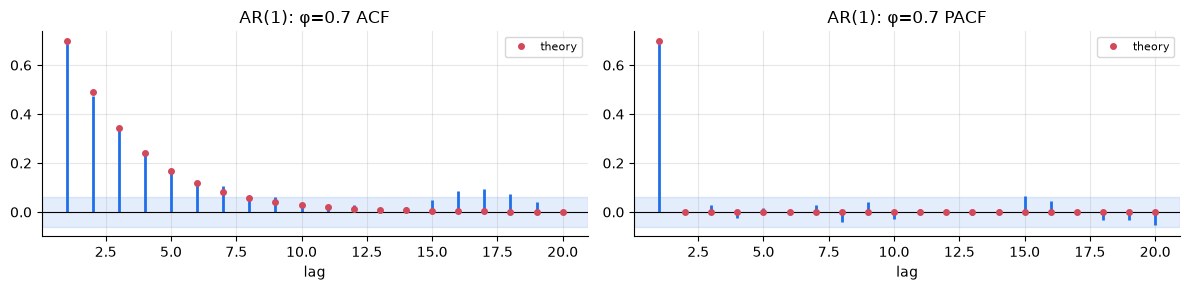

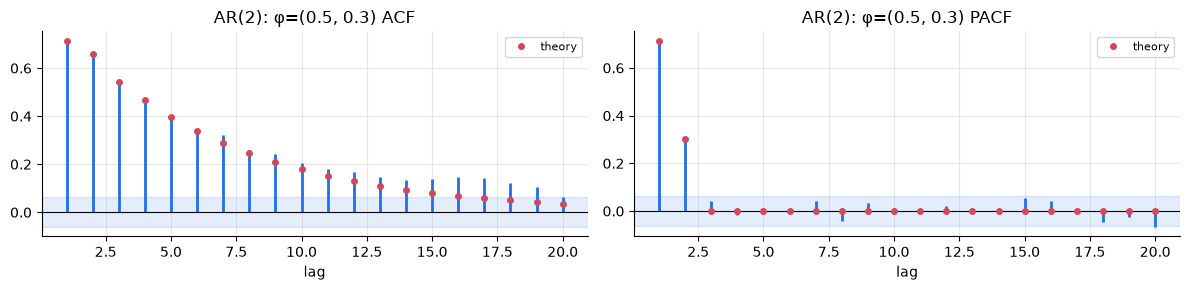

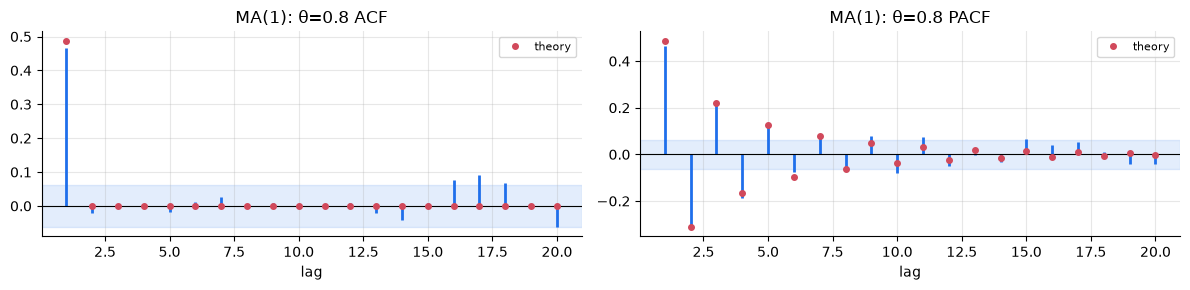

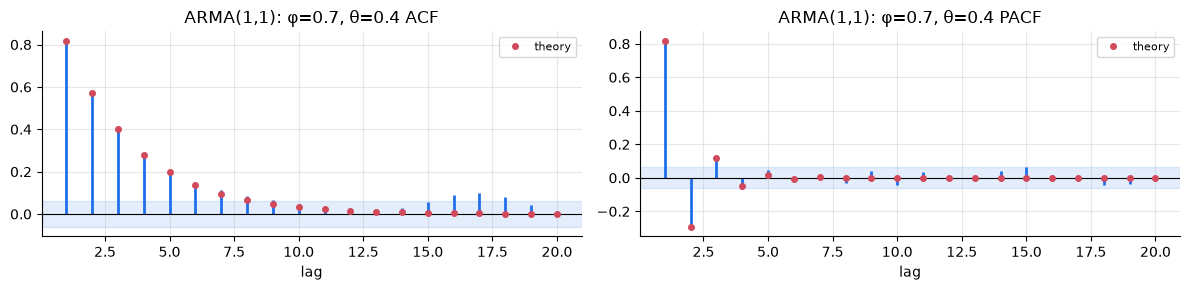

In [5]:
zoo = {
    "AR(1): φ=0.7": ([0.7], []),
    "AR(2): φ=(0.5, 0.3)": ([0.5, 0.3], []),
    "MA(1): θ=0.8": ([], [0.8]),
    "ARMA(1,1): φ=0.7, θ=0.4": ([0.7], [0.4]),
}

for name, (ar, ma) in zoo.items():
    process = ArmaProcess.from_coeffs(ar, ma)
    sample = process.generate_sample(1000, distrvs=np.random.default_rng(1).standard_normal)
    theory = {"ACF": process.acf(21)[1:], "PACF": process.pacf(21)[1:]}
    plot_acf_pacf(pd.Series(sample), lags=20, title=name, theory=theory)

The sample values (stems) follow the theory (dots) closely with 1,000 observations, and the fingerprints are clear:

- **AR(1):** the ACF decays geometrically ($0.7^k$), and the PACF has a single spike.
- **AR(2):** the ACF decays, and the PACF has two spikes.
- **MA(1):** the ACF has a single spike, and the PACF decays with alternating sign.
- **ARMA(1,1):** both tail off, so neither plot pins down the orders. That's where information criteria come in (section 6).

On real data with a few hundred points, the patterns are rarely this clean. The fingerprints are a **starting point** for identification, not a verdict.

### Stationarity and invertibility

Not every set of coefficients gives a sensible process. An AR model is **stationary** only if its coefficients don't let shocks build up. For AR(1) that means $|\phi| < 1$, and $\phi = 1$ is chapter 03's random walk. The general condition is that the roots of $1 - \phi_1 z - \dots - \phi_p z^p$ lie **outside the unit circle**. MA models have a mirror-image condition, **invertibility**, which makes the shocks recoverable from the data. `ArmaProcess` checks both:

In [6]:
for ar in ([0.7], [1.0], [0.5, 0.3], [0.5, 0.6]):
    process = ArmaProcess.from_coeffs(ar, [])
    print(f"AR coefficients {ar}: stationary = {process.isstationary}")

AR coefficients [0.7]: stationary = True
AR coefficients [1.0]: stationary = False
AR coefficients [0.5, 0.3]: stationary = True
AR coefficients [0.5, 0.6]: stationary = False


$(0.5, 0.6)$ fails even though each coefficient is below 1: together they sum above 1, and the process would explode.

---
## 4. Fitting an ARMA model

statsmodels fits ARMA models by **maximum likelihood** through its `ARIMA` class. The order is `(p, d, q)`, and the middle number is the differencing from chapter 03, which we'll use in chapter 07; for now it's 0. Let's check we can recover known coefficients from a simulated AR(2):

In [7]:
true_process = ArmaProcess.from_coeffs([0.5, 0.3], [])
simulated = true_process.generate_sample(500, distrvs=np.random.default_rng(2).standard_normal)

fit = ARIMA(simulated, order=(2, 0, 0), trend="c").fit()
pd.DataFrame({"estimate": fit.params, "std error": fit.bse,
              "true": [0, 0.5, 0.3, 1.0]}, index=["const", "φ1", "φ2", "σ²"])

,estimate,std error,true
const,-0.256,0.190,0.0
φ1,0.463,0.044,0.5
φ2,0.297,0.045,0.3
σ²,1.022,0.066,1.0


The estimates land within about two standard errors of the truth. They're close but not exact: 500 observations carry limited information, and Exercise 2 shows that AR estimates are also slightly **biased towards zero** in short series.

---
## 5. How ARMA models forecast

For an AR(1) with mean $\mu$, the forecast $h$ steps ahead is

$$\hat y_{T+h} = \mu + \phi^h\,(y_T - \mu).$$

Today's departure from the mean **decays geometrically** towards zero, exactly the *damped persistence* forecast you built by hand in chapter 04's Exercise 2. Now it's a fitted model with a proper error structure.

The forecast **variance** grows with the horizon, but only up to a limit:

$$\operatorname{Var}(y_{T+h} - \hat y_{T+h}) = \sigma^2 \,(1 + \phi^2 + \phi^4 + \dots + \phi^{2(h-1)}) \;\longrightarrow\; \frac{\sigma^2}{1 - \phi^2}.$$

For a stationary series, far-ahead uncertainty is simply the series' natural spread. Compare the random walk from chapter 03, whose uncertainty grows without limit.

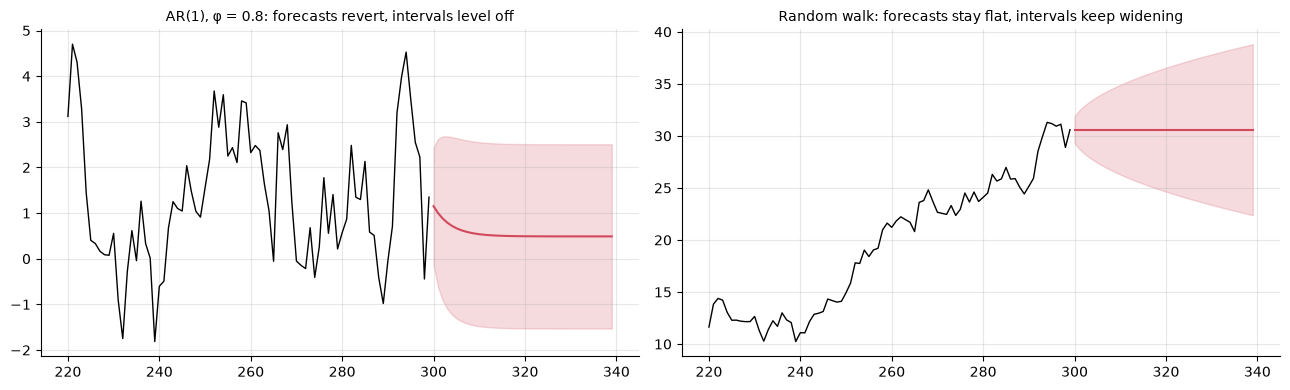

In [8]:
steps = 40
shocks = np.random.default_rng(4).normal(size=300)
ar_path = lfilter([1], [1, -0.8], shocks)      # AR(1) recursion, as in chapter 03
walk_path = np.cumsum(shocks)                  # same shocks, no reversion

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, series, order, title in [(axes[0], ar_path, (1, 0, 0), "AR(1), φ = 0.8: forecasts revert, intervals level off"),
                                 (axes[1], walk_path, (0, 1, 0), "Random walk: forecasts stay flat, intervals keep widening")]:
    result = ARIMA(series, order=order, trend="c" if order[1] == 0 else "n").fit()
    forecast = result.get_forecast(steps)
    t_future = np.arange(len(series), len(series) + steps)
    ax.plot(np.arange(len(series))[-80:], series[-80:], color="k", lw=1)
    ax.plot(t_future, forecast.predicted_mean, color="#d1495b")
    band = forecast.conf_int(alpha=0.2)
    ax.fill_between(t_future, band[:, 0], band[:, 1], color="#d1495b", alpha=0.2)
    ax.set_title(title, fontsize=10)
fig.tight_layout();

---
## 6. ARMA for Beijing PM2.5

Our series has a seasonal profile (chapter 02) that an ARMA model with a constant mean can't represent. So we split the job in two, on the log scale:

$$\log y_t = \underbrace{s(\text{day of year}_t)}_{\text{seasonal profile}} + \underbrace{a_t}_{\text{anomaly: ARMA}}$$

The profile $s$ is a log-scale climatology: the median log PM2.5 for each day of the year, smoothed over a month. It's learned **only from the history available at each origin**. `tsutils.log_climatology_profile` computes it. The ARMA model then describes how the day-to-day **anomalies** $a_t$ remember and forget.

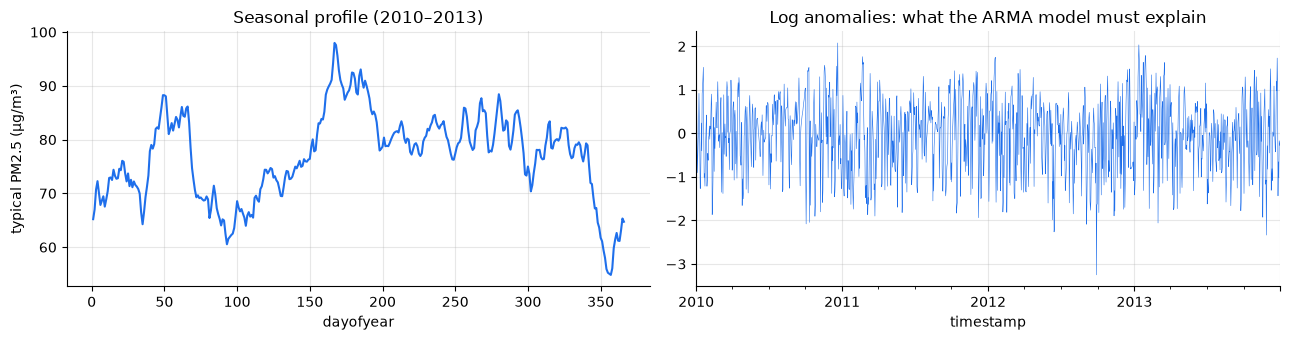

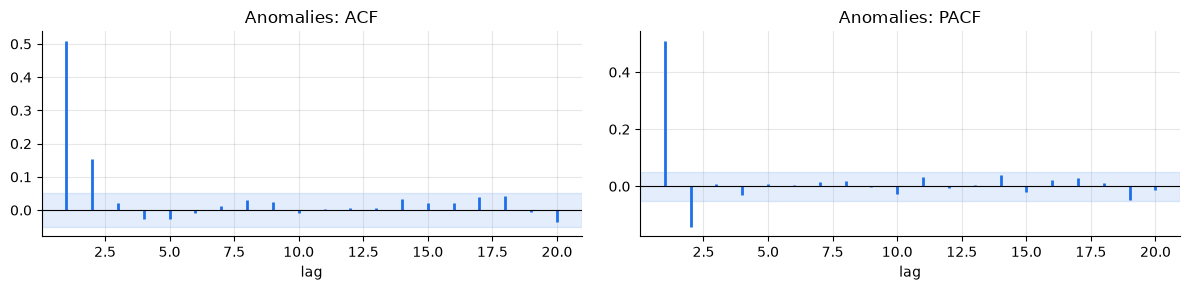

In [9]:
train = y[:"2013-12-31"]
profile = tsutils.log_climatology_profile(train)

def anomalies(series, profile):
    return np.log(series) - profile.reindex(series.index.dayofyear).to_numpy()

train_anomaly = anomalies(train, profile)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
np.exp(profile).plot(ax=axes[0], title="Seasonal profile (2010–2013)", ylabel="typical PM2.5 (µg/m³)")
train_anomaly.plot(ax=axes[1], lw=0.4, title="Log anomalies: what the ARMA model must explain")
fig.tight_layout()

plot_acf_pacf(train_anomaly, lags=20, title="Anomalies:")

The anomalies have the AR fingerprint: the **ACF decays** quickly (0.5, then about 0.15, then about 0), and the **PACF has two clear spikes**, the second one negative, and then nothing. The fingerprint suggests an **AR(2)**.

### Letting information criteria decide

Fingerprints are suggestive; information criteria are systematic. We fit every ARMA($p, q$) with $p, q \le 3$ and compare **AIC** and **BIC**. Both reward fit and penalise parameters, and BIC penalises more heavily. A few of the larger models struggle to converge; we silence those warnings here, since the criteria will rank them poorly anyway.

In [10]:
rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    for p in range(4):
        for q in range(4):
            result = ARIMA(train_anomaly.to_numpy(), order=(p, 0, q), trend="c").fit()
            rows.append({"p": p, "q": q, "AIC": result.aic, "BIC": result.bic})

ic = pd.DataFrame(rows)
ic.sort_values("AIC").head(6)

,p,q,AIC,BIC
8,2,0,3048.678,3069.826
5,1,1,3049.204,3070.351
3,0,3,3050.015,3076.449
9,2,1,3050.564,3076.998
12,3,0,3050.613,3077.047
6,1,2,3050.921,3077.356


In [11]:
ic.pivot(index="p", columns="q", values="BIC").style.format("{:.1f}").highlight_min(axis=None, color="#cfe3ff")

q,0,1,2,3
p,,,,
0,3525.1,3104.3,3073.7,3076.4
1,3092.6,3070.4,3077.4,3083.7
2,3069.8,3077.0,3083.6,3090.1
3,3077.0,3083.6,3090.3,3096.1


**AR(2)** comes out on top on both criteria, agreeing with the PACF. ARMA(1,1) is a close second, and it produces nearly identical forecasts. When two models are this close, prefer the simpler or more interpretable one, and let the backtest have the final word.

### Residual checks: has the model captured the memory?

If a model has captured the series' memory, its residuals should look like **white noise**. The **Ljung–Box test** checks many residual autocorrelations at once. Its null hypothesis is "no autocorrelation up to lag $m$", so here we *want* large p-values.

In [12]:
fits = {name: ARIMA(train_anomaly.to_numpy(), order=order, trend="c").fit()
        for name, order in [("AR(1)", (1, 0, 0)), ("AR(2)", (2, 0, 0))]}

pd.concat({name: acorr_ljungbox(f.resid, lags=[7, 14]) for name, f in fits.items()}).rename_axis(["model", "lags"])

lb_stat  lb_pvalue
model lags                    
AR(1) 7      30.739  6.946e-05
      14     36.750  8.049e-04
AR(2) 7       1.437  9.844e-01
      14      8.279  8.743e-01

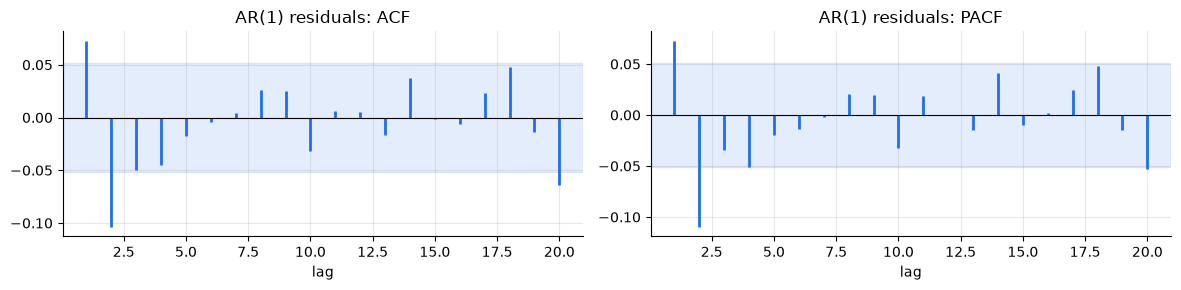

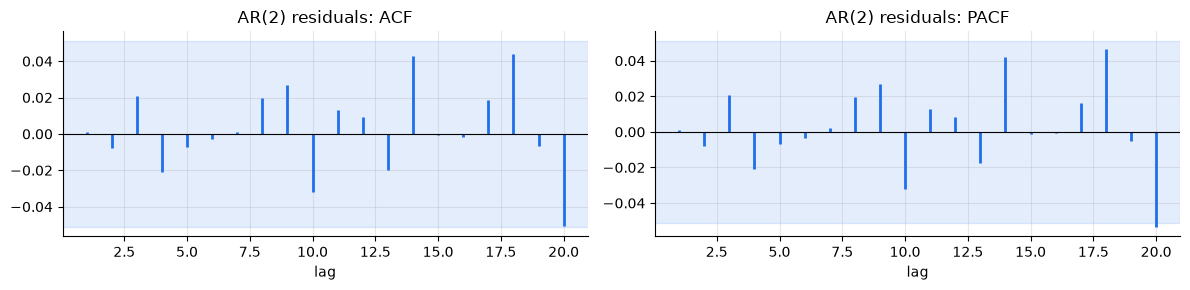

In [13]:
plot_acf_pacf(pd.Series(fits["AR(1)"].resid), lags=20, title="AR(1) residuals:")
plot_acf_pacf(pd.Series(fits["AR(2)"].resid), lags=20, title="AR(2) residuals:")

**AR(1) fails**: its residuals still show a positive spike at lag 1 and a larger negative one at lag 2, both outside the band, and Ljung–Box rejects white noise decisively. **AR(2) passes**. That second coefficient isn't decoration: it captures how quickly episodes **clear**, a little faster than a single geometric decay would allow.

In [14]:
fits["AR(2)"].summary().tables[1]

,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0359,0.036,-0.991,0.322,-0.107,0.035
ar.L1,0.5826,0.027,21.811,0.000,0.530,0.635
ar.L2,-0.1427,0.025,-5.661,0.000,-0.192,-0.093
sigma2,0.4691,0.018,26.489,0.000,0.434,0.504


---
## 7. The backtest

Now the real test, on the chapter 04 setup. At every origin we **re-learn the profile and refit the ARMA model** from the history alone, forecast the anomalies, add back the profile, and exponentiate. That gives a median-type forecast on the original scale, which suits MAE (chapter 04). We'll also collect the model's 80% prediction intervals as we go.

In [15]:
def arma_forecaster(order, intervals=None):
    """Seasonal log profile + ARMA(order) on anomalies, refitted on each history."""
    def forecast(history, horizon):
        profile_ = tsutils.log_climatology_profile(history)
        anomaly = anomalies(history, profile_)
        result = ARIMA(anomaly.to_numpy(), order=order, trend="c").fit()
        prediction = result.get_forecast(horizon)
        targets = pd.date_range(history.index[-1] + pd.Timedelta(days=1), periods=horizon, freq="D")
        seasonal = profile_.reindex(targets.dayofyear).to_numpy()
        if intervals is not None:
            band = prediction.conf_int(alpha=0.2)
            intervals[history.index[-1]] = np.exp(band + seasonal[:, None])
        return np.exp(prediction.predicted_mean + seasonal)
    return forecast

ar2_intervals = {}
arma_scores = {
    "AR(1) on anomalies": tsutils.evaluate(tsutils.backtest(y, arma_forecaster((1, 0, 0)), origins, H, actuals=actual)),
    "AR(2) on anomalies": tsutils.evaluate(tsutils.backtest(y, arma_forecaster((2, 0, 0), ar2_intervals),
                                                            origins, H, actuals=actual)),
}
for name, scores in arma_scores.items():
    tsutils.save_scores(name, scores)

board = tsutils.load_scores().pivot(index="h", columns="model", values="MAE")
board[["naive", "climatology (median)", "SES (log), α per horizon", "AR(1) on anomalies", "AR(2) on anomalies"]]

model,naive,climatology (median),"SES (log), α per horizon",AR(1) on anomalies,AR(2) on anomalies
h,,,,,
1,51.105,56.079,52.135,47.737,46.803
2,72.237,56.561,56.283,56.563,55.419
3,81.266,56.771,56.078,57.349,56.264
4,81.559,57.133,56.347,56.869,56.533
5,76.293,57.099,56.310,56.475,56.587
6,75.097,57.132,56.320,56.455,56.491
7,76.937,57.068,56.261,56.417,56.407


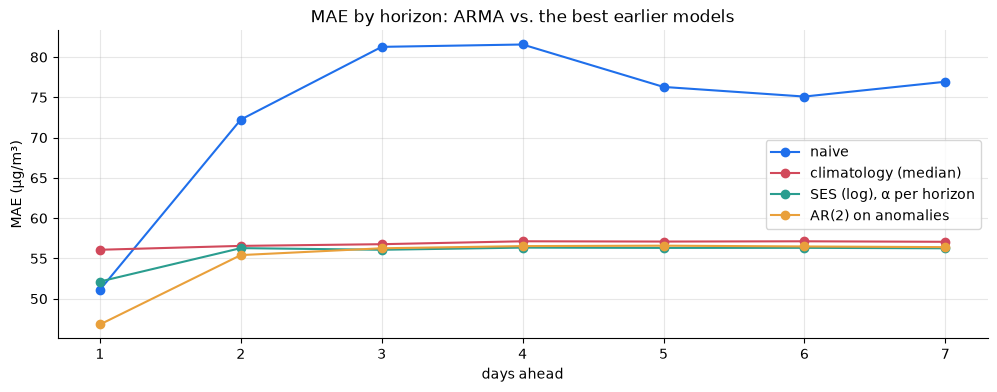

In [16]:
fig, ax = plt.subplots()
for name in ["naive", "climatology (median)", "SES (log), α per horizon", "AR(2) on anomalies"]:
    ax.plot(board.index, board[name], marker="o", label=name)
ax.set(title="MAE by horizon: ARMA vs. the best earlier models", xlabel="days ahead", ylabel="MAE (µg/m³)")
ax.legend();

**The first model to lead at both ends.**

- **One day ahead**, AR(2) is the best forecast so far, clearly ahead of naive, the previous leader. It uses today's anomaly, but only as much of it as the data say survives to tomorrow.
- **Two days ahead** it's also the best, about 1 µg/m³ ahead of both climatology and the per-horizon SES.
- **From about day 3**, it settles to the same level as climatology and the long-memory SES. That isn't a failure. The forecast has decayed back to the seasonal profile because, as chapter 03 found, the series has forgotten today's conditions by then. **No model that uses only past PM2.5 can do much better at those horizons.** The remaining information is in things the series itself doesn't contain, above all the **weather forecast**, which chapters 07 and 09 bring in.

AR(2) also edges out AR(1) at short horizons, as the residual checks predicted.

### Are the intervals honest?

In [17]:
rows = []
for origin_, band in ar2_intervals.items():
    dates = pd.date_range(origin_ + pd.Timedelta(days=1), periods=H, freq="D")
    rows.append(pd.DataFrame({"h": np.arange(1, H + 1), "lower": band[:, 0], "upper": band[:, 1],
                              "actual": actual.reindex(dates).to_numpy()}))
scored = pd.concat(rows).dropna(subset=["actual"])
inside = (scored["actual"] >= scored["lower"]) & (scored["actual"] <= scored["upper"])
inside.groupby(scored["h"]).mean().rename("coverage of 80% interval").to_frame().T.style.format("{:.0%}")

h,1,2,3,4,5,6,7
coverage of 80% interval,80%,78%,78%,78%,78%,78%,78%


The AR(2) intervals come out close to the 80% they promise across horizons, without any calibration step. Working on the log scale helps: there, the anomalies are close to the constant-variance, roughly normal errors the model assumes. The intervals also **widen from day 1 to day 2 and then stop**. That's section 5's theory showing up in real data: beyond a couple of days, the uncertainty is simply the natural spread of PM2.5 at that time of year.

---
## Exercises

### Exercise 1: Identify these processes
For each of the three processes below, simulate 800 observations with `ArmaProcess.from_coeffs(...).generate_sample(...)`, plot the ACF and PACF, and guess the orders **before** checking with an AIC grid over $p, q \le 2$:
- A: AR coefficients `[0.6, -0.3]`, no MA
- B: no AR, MA coefficients `[0.6, 0.4]`
- C: AR `[0.8]`, MA `[-0.5]`

<details><summary>Solution</summary>

```python
mystery = {"A": ([0.6, -0.3], []), "B": ([], [0.6, 0.4]), "C": ([0.8], [-0.5])}
for label, (ar, ma) in mystery.items():
    sample = ArmaProcess.from_coeffs(ar, ma).generate_sample(800, distrvs=np.random.default_rng(10).standard_normal)
    plot_acf_pacf(pd.Series(sample), lags=15, title=f"Process {label}:")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")          # start-up and convergence warnings from poor candidate orders
        aic = {(p, q): ARIMA(sample, order=(p, 0, q), trend="c").fit().aic for p in range(3) for q in range(3)}
    print(label, "-> lowest AIC at (p, q) =", min(aic, key=aic.get))
```
A is an **AR(2)**: the ACF oscillates as it decays, and the PACF cuts off after lag 2. B is an **MA(2)**: the ACF cuts off after lag 2. C is an **ARMA(1,1)**: both plots tail off, and it's the hardest to identify by eye. AIC usually finds the right orders here, but with less data or smaller coefficients it can pick a neighbouring model that forecasts almost identically. That's fine for forecasting, less so if you want to interpret the coefficients.
</details>

### Exercise 2: AR estimates are biased in short series
Simulate 500 AR(1) series with φ = 0.9 at each length n = 50, 200 and 1000. Fit each by least squares with `AutoReg(x, lags=1, trend="c")`, which is much faster than `ARIMA` for 1,500 fits and has the same small-sample bias. Compare the average estimate with the true value and with Kendall's approximation for the expected estimate, $\phi - (1 + 3\phi)/n$.

<details><summary>Solution</summary>

```python
process = ArmaProcess.from_coeffs([0.9], [])
sim_rng = np.random.default_rng(3)
rows = []
for n in [50, 200, 1000]:
    estimates = [AutoReg(process.generate_sample(n, distrvs=sim_rng.standard_normal, burnin=200),
                         lags=1, trend="c").fit().params[1] for _ in range(500)]
    rows.append({"n": n, "mean estimate": np.mean(estimates),
                 "Kendall approximation": 0.9 - (1 + 3 * 0.9) / n, "spread (sd)": np.std(estimates)})
pd.DataFrame(rows).set_index("n")
```
With 50 observations the average estimate falls noticeably short of 0.9, close to Kendall's formula. The bias shrinks as n grows. Estimating the mean from the same short sample makes the series look more mean-reverting than it really is. For forecasting that means **short histories understate persistence**, which is one reason models fitted on a few months of data revert too fast.
</details>

### Exercise 3: Pseudo-cycles from AR(2)
An AR(2) whose characteristic roots are complex produces **pseudo-cycles**: waves with a typical, but not fixed, length. Take φ = (1.0, −0.5). Use `ArmaProcess.from_coeffs([1.0, -0.5], []).arroots` to get the roots, and compute the implied period $2\pi / |\text{angle}|$. Then simulate 500 points, plot them, and plot the theoretical ACF for 30 lags. Does the ACF oscillate with that period?

<details><summary>Solution</summary>

```python
process = ArmaProcess.from_coeffs([1.0, -0.5], [])
roots = process.arroots
period = 2 * np.pi / np.abs(np.angle(roots[0]))
print("roots:", np.round(roots, 3), f"-> period ≈ {period:.1f} steps")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(process.generate_sample(500, distrvs=np.random.default_rng(6).standard_normal), lw=0.8)
axes[0].set_title("AR(2) with complex roots: irregular waves")
axes[1].stem(process.acf(31)[1:])
axes[1].set_title(f"Theoretical ACF: damped oscillation, period ≈ {period:.0f}")
fig.tight_layout()
```
The period is 8 steps, and the ACF swings through a full cycle roughly every 8 lags while decaying. The simulated series shows waves of roughly that length, but irregular, because shocks keep nudging the phase. This is how AR models represent quasi-periodic behaviour such as business cycles, and why they aren't the same as fixed seasonality.
</details>

### Exercise 4: AR(1) forecasts are damped persistence
Fit an AR(1) with a constant to `train_anomaly`. From the fitted mean $\mu$ (in statsmodels, the `const` parameter *is* the mean) and $\phi$, compute $\mu + \phi^h (a_T - \mu)$ for $h = 1, \dots, 7$ by hand, where $a_T$ is the last training anomaly. Check that it matches `fit.forecast(7)`, then work out the half-life of an anomaly in days.

<details><summary>Solution</summary>

```python
fit1 = ARIMA(train_anomaly.to_numpy(), order=(1, 0, 0), trend="c").fit()
mu, phi = fit1.params[0], fit1.params[1]
last = train_anomaly.iloc[-1]
by_hand = mu + phi ** np.arange(1, 8) * (last - mu)
print("matches statsmodels:", np.allclose(by_hand, fit1.forecast(7)))
print(f"φ = {phi:.2f} -> half-life ≈ {np.log(0.5) / np.log(phi):.1f} days")
```
The two agree exactly. The half-life, about a day, matches chapter 03's estimate from the raw series. Now it comes from a fitted model with standard errors and intervals, instead of a hand-built rule.
</details>

---
## Key takeaways

- The **ACF** measures a series' total memory at each lag. The **PACF** measures the *direct* part, after removing intermediate lags. Both are easy to compute from scratch.
- **AR($p$):** ACF tails off, PACF cuts off after $p$. **MA($q$):** the reverse. **ARMA:** both tail off, so use **AIC/BIC** and let the backtest decide.
- ARMA forecasts **revert to the mean** geometrically, and their intervals **level off** at the series' natural spread, unlike a random walk's.
- Check residuals with **Ljung–Box**. On PM2.5 anomalies, AR(1) left structure behind and AR(2) didn't.
- **Seasonal profile + AR(2) on log anomalies** is the best model on the scoreboard at 1 and 2 days ahead, with well-calibrated intervals. Beyond that, *no* model built on past PM2.5 alone does much better than climatology. The next gains must come from **outside information**.

**Next:** *07 · ARIMA, SARIMA and SARIMAX*. We'll add differencing and seasonal terms (and CO₂ will show why they matter), then feed **weather** into the model as exogenous inputs.